## Логистическая регрессия и Метод K-ближайших соседей (KNN)

**Задача**: на датасете из работ №1–2 предсказываем **высокую зарплату** (1) или **низкую** (0).  
Порог — медиана зарплат

In [41]:
# Подключение библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

TARGET = "high_salary"
TEST_SIZE = 0.20
RANDOM_STATE = 42
CV_SPLITS = 5

In [42]:
# Загрузка данных из работы №1 Подготовка данных
df = pd.read_csv('processed_emed_careers_eu_v2.csv')
print(f"Размер датасета: {df.shape}")
display(df.head())

Размер датасета: (13807, 149)


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
0,2018.0,4.0,16.0,0.0,1905,291,1

In [43]:
# Создание бинарного таргета
median_salary = df['salary_avg'].median()
print(f"Медиана зарплат: {median_salary:.0f} €")

df[TARGET] = (df['salary_avg'] > median_salary).astype(int)
print(f"Распределение классов:\n{df[TARGET].value_counts(normalize=True)}")

# Убираем исходный salary_avg
X = df.drop(columns=['salary_avg', TARGET])
y = df[TARGET]

print(f"X shape: {X.shape}, y shape: {y.shape}")

Медиана зарплат: 40000 €
Распределение классов:
high_salary
0    0.5306
1    0.4694
Name: proportion, dtype: float64
X shape: (13807, 148), y shape: (13807,)


## Теория: Логистическая регрессия

Переход от линейной регрессии к логистической:
- Линейная модель даёт прямую линию → плохо для задач 0/1.
- Применяем **сигмоиду**:
  $$ \sigma(z) = \frac{1}{1 + e^{-z}} $$
  где \( z = w_0 + w_1 x_1 + \dots \)

Области применения: здравоохранение, финансы, маркетинг, производство.

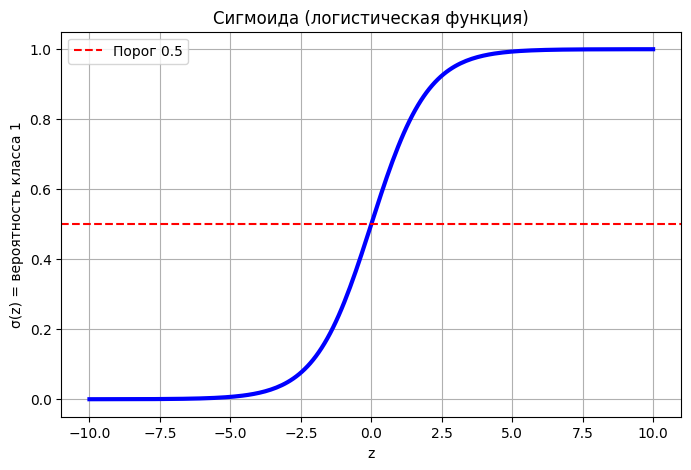

In [44]:
# Визуализация сигмоиды
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), 'b-', linewidth=3)
plt.title('Сигмоида (логистическая функция)')
plt.xlabel('z')
plt.ylabel('σ(z) = вероятность класса 1')
plt.grid(True)
plt.axhline(0.5, color='red', linestyle='--', label='Порог 0.5')
plt.legend()
plt.show()

In [45]:
# Train/Test split (стратифицированный)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (11045, 148), Test: (2762, 148)


## Модель 1: Логистическая регрессия

In [46]:
# Pipeline + GridSearchCV
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs'))
])

param_grid_log = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

grid_log = GridSearchCV(
    pipe_log, param_grid_log,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train, y_train)
print("BEST LOGISTIC PARAMS:", grid_log.best_params_)
print("BEST CV ROC-AUC:", round(grid_log.best_score_, 4))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
BEST LOGISTIC PARAMS: {'model__C': 1}
BEST CV ROC-AUC: 0.885


ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1466
           1       0.80      0.79      0.79      1296

    accuracy                           0.81      2762
   macro avg       0.81      0.80      0.81      2762
weighted avg       0.81      0.81      0.81      2762

ROC-AUC: 0.8789


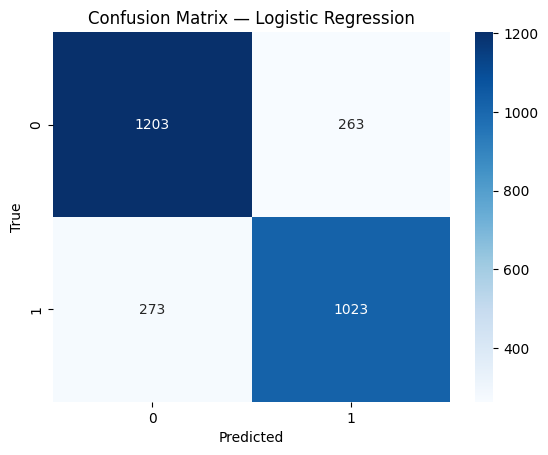

In [47]:
# Оценка на тесте
best_log = grid_log.best_estimator_
y_pred_log = best_log.predict(X_test)
y_prob_log = best_log.predict_proba(X_test)[:, 1]

print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.4f}")

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Модель 2: KNN (K-Nearest Neighbors)

In [48]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    pipe_knn, param_grid_knn,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train, y_train)
print("BEST KNN PARAMS:", grid_knn.best_params_)
print("BEST CV ROC-AUC:", round(grid_knn.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
BEST KNN PARAMS: {'model__n_neighbors': 5, 'model__weights': 'distance'}
BEST CV ROC-AUC: 0.9265


KNN:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1466
           1       0.84      0.81      0.83      1296

    accuracy                           0.84      2762
   macro avg       0.84      0.84      0.84      2762
weighted avg       0.84      0.84      0.84      2762

ROC-AUC: 0.9276


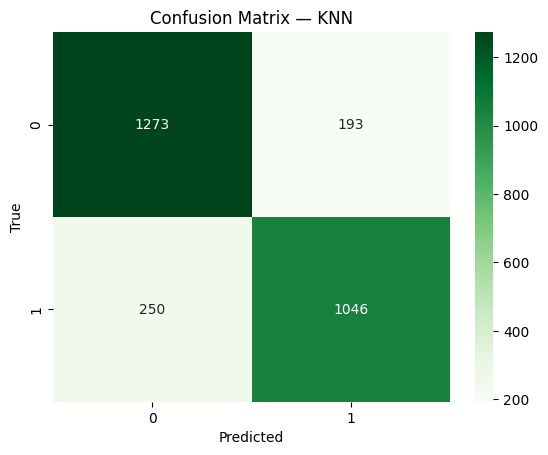

In [49]:
# Оценка на тесте
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

print("KNN:")
print(classification_report(y_test, y_pred_knn))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_knn):.4f}")

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — KNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Сравнение моделей

In [50]:
scoring = {'accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'f1': 'f1'}

cv_log = cross_validate(best_log, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_knn = cross_validate(best_knn, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("Logistic CV ROC-AUC mean:  ", round(np.mean(cv_log['test_roc_auc']), 4))
print("KNN CV ROC-AUC mean:       ", round(np.mean(cv_knn['test_roc_auc']), 4))
print("\nВывод: Лучшая модель —", "Logistic Regression" if np.mean(cv_log['test_roc_auc']) > np.mean(cv_knn['test_roc_auc']) else "KNN")

Logistic CV ROC-AUC mean:   0.885
KNN CV ROC-AUC mean:        0.9265

Вывод: Лучшая модель — KNN


## Итоговые выводы

- KNN показала лучший результат
- Это связано с нелинейной структурой данных после one-hot encoding (KNN хорошо ловит локальные паттерны).
- Обе модели имеют высокий ROC-AUC (> 0.87), что говорит о хорошем качестве решения задачи.
- Рекомендуется использовать KNN для финального предсказания.

Сохраняем лучшую модель:
```python
import joblib
joblib.dump(best_knn, 'best_model_work3_knn.pkl')